# Credit Risk Prediction - Final Consolidated Notebook

This notebook presents a leakage-safe credit-risk Probability of Default modeling workflow.

**Main corrections and improvements:**

- Uses `Status` as the loan outcome target.
- Keeps `Default` as prior default history, not as the target.
- Fits imputation, encoding, feature engineering, model tuning, and threshold selection only on training/validation data.
- Avoids full-dataset Weight of Evidence encoding because it leaks target information when computed before splitting.
- Evaluates final results on a held-out test set that is not used for tuning.
- Adds probability calibration because credit-risk projects need useful probability-of-default estimates, not only class labels.

## Final Verified Results

The latest leakage-safe run produced the following held-out test results for the final refit XGBoost classifier using a validation-selected threshold:

| Metric | Value |
|---|---:|
| ROC-AUC | 0.9477 |
| PR-AUC | 0.8994 |
| Accuracy | 92.70% |
| Precision | 91.06% |
| Recall | 73.77% |
| F1-score | 81.51% |
| KS Statistic | 0.7572 |

A separately calibrated probability-of-default model improved Brier score from about `0.0704` to `0.0597` using sigmoid calibration.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from xgboost import XGBClassifier

RANDOM_STATE = 42
DATA_PATH = Path("data/raw/credit_risk.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../data/raw/credit_risk.csv")

TARGET = "Status"

pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid")

## Load Source Data

The workflow uses `data/raw/credit_risk.csv` as the source file. The raw source file is used instead of derived cleaned data so preprocessing can be fitted safely after the train/validation/test split.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
display(df.head())

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_rate": df.isna().mean().round(4),
    "n_unique": df.nunique(),
})
display(audit)

Shape: (32581, 12)


,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4


,dtype,missing,missing_rate,n_unique
Id,int64,0,0.0000,32581
Age,int64,0,0.0000,58
Income,int64,0,0.0000,4295
Home,object,0,0.0000,4
Emp_length,float64,895,0.0275,36
Intent,object,0,0.0000,6
Amount,int64,0,0.0000,753
Rate,float64,3116,0.0956,348
Status,int64,0,0.0000,2
Percent_income,float64,0,0.0000,77


## Target Definition

`Status` is the loan outcome target. `Default` is prior default history and remains a predictor.

In [3]:
print("Target distribution for Status:")
display(df[TARGET].value_counts().rename("count"))
print(f"Positive class rate: {df[TARGET].mean():.2%}")

print("Relationship between Status and prior Default history:")
display(pd.crosstab(df[TARGET], df["Default"], normalize="index").round(3))

Target distribution for Status:


Status
0    25473
1     7108
Name: count, dtype: int64

Positive class rate: 21.82%
Relationship between Status and prior Default history:


Default,N,Y
Status,,
0,0.860,0.140
1,0.694,0.306


## Data Quality Notes

The raw data contains impossible values such as very high age or employment length. The feature engineering transformer below handles these with domain-safe rules that do not use the target.

In [4]:
print("Age above 100:", (df["Age"] > 100).sum())
print("Employment length above 60:", (df["Emp_length"] > 60).sum())
print("Missing interest rate:", df["Rate"].isna().sum())
print("Missing employment length:", df["Emp_length"].isna().sum())
print("Duplicate rows:", df.duplicated().sum())

Age above 100: 5
Employment length above 60: 2
Missing interest rate: 3116
Missing employment length: 895
Duplicate rows: 0


## Exploratory Data Analysis

This section covers the original assignment requirement for summary statistics, key feature distributions, and default-risk relationships across borrower groups.

,count,mean,std,min,25%,50%,75%,max
Age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
Income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
Emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
Amount,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
Rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
Percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
Cred_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00
Status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00


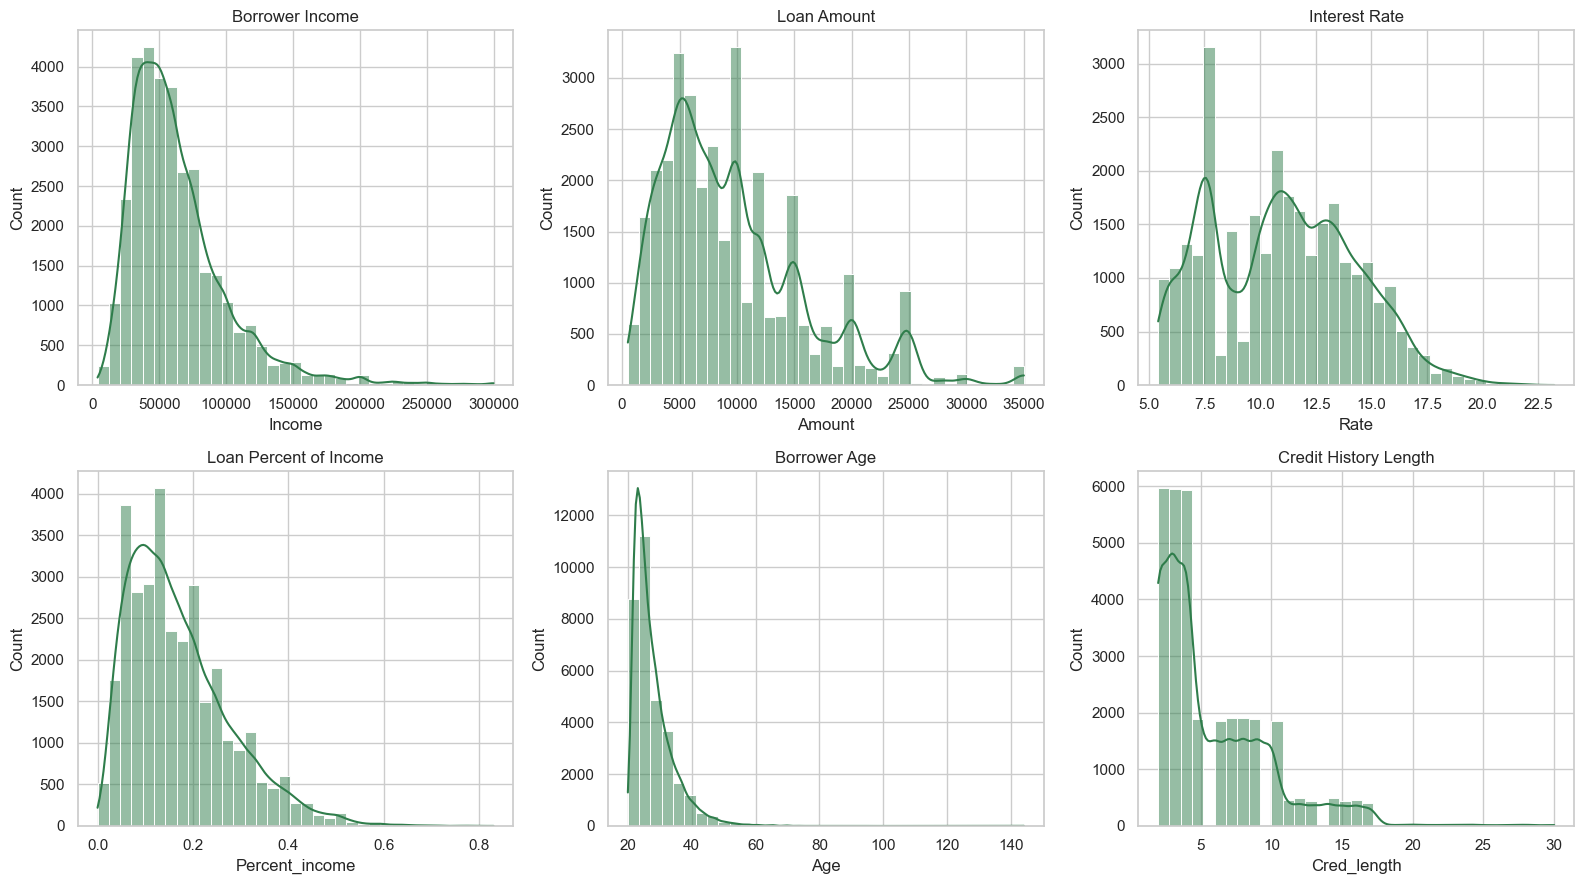

In [5]:
eda_numeric_cols = ["Age", "Income", "Emp_length", "Amount", "Rate", "Percent_income", "Cred_length"]
display(df[eda_numeric_cols + [TARGET]].describe().T)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [
    ("Income", "Borrower Income", True),
    ("Amount", "Loan Amount", False),
    ("Rate", "Interest Rate", False),
    ("Percent_income", "Loan Percent of Income", False),
    ("Age", "Borrower Age", False),
    ("Cred_length", "Credit History Length", False),
]

for ax, (column, title, clip_tail) in zip(axes.ravel(), plot_specs):
    values = df[column].dropna()
    if clip_tail:
        values = values[values <= values.quantile(0.995)]
    sns.histplot(values, bins=35, kde=True, ax=ax, color="#2f7d4b")
    ax.set_title(title)
    ax.set_xlabel(column)

plt.tight_layout()
plt.show()

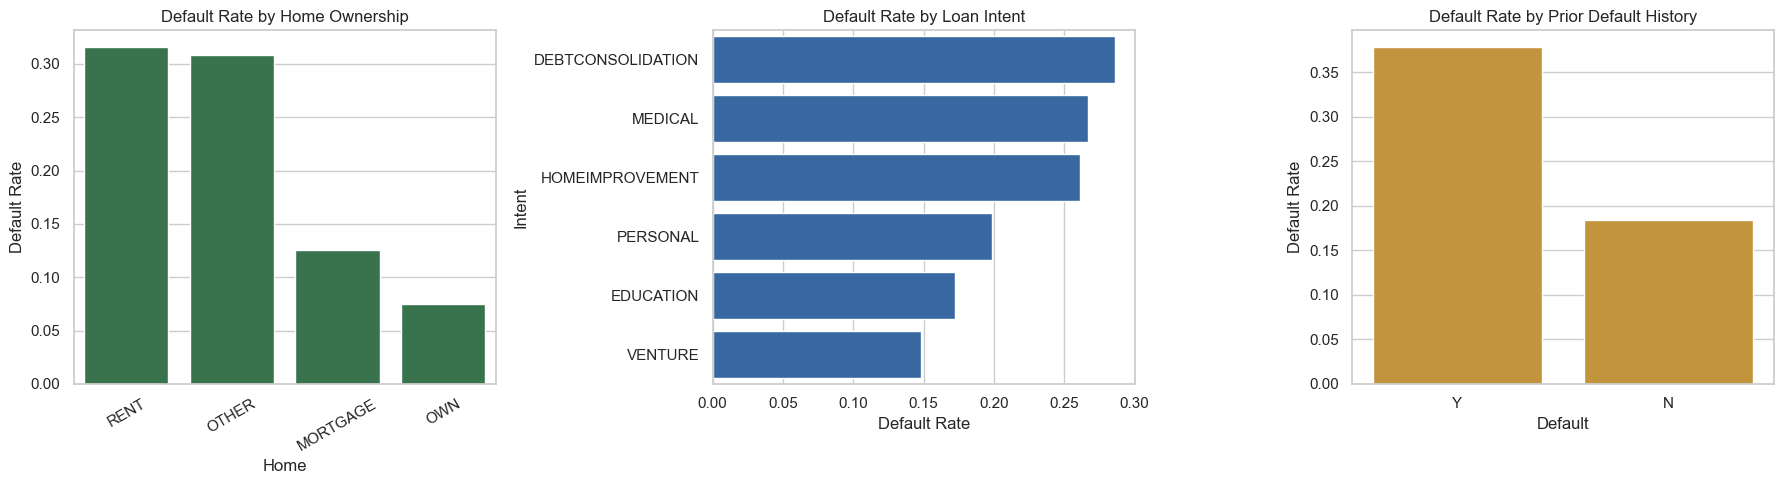

,home_default_rate
Home,
RENT,31.57%
OTHER,30.84%
MORTGAGE,12.57%
OWN,7.47%


,intent_default_rate
Intent,
DEBTCONSOLIDATION,28.59%
MEDICAL,26.70%
HOMEIMPROVEMENT,26.10%
PERSONAL,19.89%
EDUCATION,17.22%
VENTURE,14.81%


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

home_default = df.groupby("Home")[TARGET].mean().sort_values(ascending=False)
intent_default = df.groupby("Intent")[TARGET].mean().sort_values(ascending=False)
prior_default = df.groupby("Default")[TARGET].mean().sort_values(ascending=False)

sns.barplot(x=home_default.index, y=home_default.values, ax=axes[0], color="#2f7d4b")
axes[0].set_title("Default Rate by Home Ownership")
axes[0].set_ylabel("Default Rate")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(x=intent_default.values, y=intent_default.index, ax=axes[1], color="#2867b2")
axes[1].set_title("Default Rate by Loan Intent")
axes[1].set_xlabel("Default Rate")

sns.barplot(x=prior_default.index, y=prior_default.values, ax=axes[2], color="#d99a28")
axes[2].set_title("Default Rate by Prior Default History")
axes[2].set_ylabel("Default Rate")

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "home_default_rate": home_default,
}).style.format("{:.2%}"))
display(pd.DataFrame({
    "intent_default_rate": intent_default,
}).style.format("{:.2%}"))

## Leakage-Safe Feature Engineering

This transformer is placed inside the sklearn pipeline, so the same logic is applied consistently during training, validation, testing, and future inference.

In [7]:
class CreditFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if "Default" in X.columns:
            X["Default"] = (
                X["Default"]
                .astype(str)
                .str.strip()
                .str.upper()
                .map({"Y": 1, "N": 0})
                .fillna(0)
                .astype(int)
            )

        X["Age"] = X["Age"].mask((X["Age"] < 18) | (X["Age"] > 100), np.nan)
        X["Emp_length"] = X["Emp_length"].mask((X["Emp_length"] < 0) | (X["Emp_length"] > 60), np.nan)
        X["Emp_length"] = np.minimum(X["Emp_length"], (X["Age"] - 14).clip(lower=0))

        income = X["Income"].replace(0, np.nan)
        amount = X["Amount"]
        rate = X["Rate"]
        credit_length = X["Cred_length"].replace(0, np.nan)
        employment = X["Emp_length"]

        X["Loan_to_Income"] = amount / income
        X["Annual_Interest"] = amount * rate / 100
        X["Emp_to_Credit_Ratio"] = employment / credit_length
        X["Amount_per_Cred_Length"] = amount / credit_length
        X["Rate_x_Amount"] = rate * amount

        return X


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(raw_feature_columns, add_missing_indicators=True, scale_numeric=True):
    engineered_columns = CreditFeatureEngineer().transform(
        pd.DataFrame(columns=raw_feature_columns)
    ).columns.tolist()

    categorical_features = ["Home", "Intent"]
    numeric_features = [c for c in engineered_columns if c not in categorical_features]

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=add_missing_indicators))
    ]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(numeric_steps), numeric_features),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_one_hot_encoder()),
                ]),
                categorical_features,
            ),
        ],
        remainder="drop",
    )


def make_pipeline(model, raw_feature_columns, add_missing_indicators=True, scale_numeric=True):
    return Pipeline([
        ("features", CreditFeatureEngineer()),
        ("preprocess", make_preprocessor(raw_feature_columns, add_missing_indicators, scale_numeric)),
        ("model", model),
    ])

## Train / Validation / Test Split

The final test set is held out until the end. Hyperparameters and classification thresholds are selected without using test labels.

In [8]:
model_df = df.drop(columns=["Id"], errors="ignore").copy()
y = model_df[TARGET].astype(int)
X = model_df.drop(columns=[TARGET])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_full
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])
print("Train positive rate:", y_train.mean().round(4))
print("Validation positive rate:", y_val.mean().round(4))
print("Test positive rate:", y_test.mean().round(4))

Train size: 19548
Validation size: 6516
Test size: 6517
Train positive rate: 0.2182
Validation positive rate: 0.2181
Test positive rate: 0.2182


## Evaluation Helpers

In [9]:
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))


def find_best_threshold(y_true, y_prob, metric="f1"):
    thresholds = np.linspace(0.05, 0.95, 361)
    best_threshold = 0.5
    best_score = -np.inf

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_true, y_pred)
        elif metric == "fbeta2":
            score = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        else:
            raise ValueError(f"Unknown metric: {metric}")

        if score > best_score:
            best_threshold = float(threshold)
            best_score = float(score)

    return best_threshold, best_score


def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "threshold": float(threshold),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "fbeta2": float(fbeta_score(y_true, y_pred, beta=2, zero_division=0)),
        "ks": ks_statistic(y_true, y_prob),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def evaluate_model_with_validation_threshold(name, pipeline):
    pipeline.fit(X_train, y_train)
    val_prob = pipeline.predict_proba(X_val)[:, 1]
    threshold, val_f1 = find_best_threshold(y_val, val_prob, metric="f1")
    test_prob = pipeline.predict_proba(X_test)[:, 1]
    metrics = evaluate_predictions(y_test, test_prob, threshold)
    metrics["model"] = name
    metrics["validation_f1"] = val_f1
    return metrics, pipeline

## Baseline Model Comparison

These models use the same leakage-safe preprocessing pipeline. Thresholds are selected on validation data and then evaluated once on the test set.

In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs"),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=450,
        learning_rate=0.04,
        max_leaf_nodes=31,
        l2_regularization=0.01,
        random_state=RANDOM_STATE,
    ),
    "XGBoost Baseline": XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        n_estimators=700,
        max_depth=4,
        learning_rate=0.035,
        subsample=0.9,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_lambda=2.0,
        reg_alpha=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

comparison_rows = []
fitted_baselines = {}
for name, model in candidate_models.items():
    pipeline = make_pipeline(model, X.columns.tolist(), add_missing_indicators=True, scale_numeric=True)
    metrics, fitted_pipeline = evaluate_model_with_validation_threshold(name, pipeline)
    comparison_rows.append(metrics)
    fitted_baselines[name] = fitted_pipeline

comparison = pd.DataFrame(comparison_rows).sort_values(["roc_auc", "f1"], ascending=False)
display(comparison[[
    "model", "threshold", "roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1", "ks", "brier"
]].style.format({
    "threshold": "{:.3f}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
    "accuracy": "{:.2%}",
    "precision": "{:.2%}",
    "recall": "{:.2%}",
    "f1": "{:.2%}",
    "ks": "{:.4f}",
    "brier": "{:.4f}",
}))

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,ks,brier
3,XGBoost Baseline,0.712,0.9393,0.8866,92.17%,93.76%,68.71%,79.30%,0.7336,0.0788
2,Hist Gradient Boosting,0.500,0.9357,0.8849,92.36%,95.38%,68.28%,79.59%,0.7319,0.0606
1,Random Forest,0.482,0.9191,0.8609,91.30%,87.67%,69.97%,77.83%,0.7000,0.0736
0,Logistic Regression,0.622,0.8656,0.7098,83.57%,60.80%,69.48%,64.85%,0.5783,0.1473


## Hyperparameter Tuning

The random search is intentionally performed on the training split only. Validation data is kept for threshold selection.

Set `RUN_RANDOM_SEARCH = False` to use the best parameters already found during the improvement pass.

In [11]:
RUN_RANDOM_SEARCH = False

BEST_XGB_PARAMS = {
    "subsample": 0.95,
    "reg_lambda": 1.5,
    "reg_alpha": 0.02,
    "n_estimators": 1100,
    "min_child_weight": 2,
    "max_depth": 5,
    "learning_rate": 0.05,
    "gamma": 0,
    "colsample_bytree": 0.8,
}
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_search_pipeline = make_pipeline(
    xgb_base, X.columns.tolist(), add_missing_indicators=True, scale_numeric=True
)

if RUN_RANDOM_SEARCH:
    param_dist = {
        "model__n_estimators": [500, 700, 900, 1100],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.02, 0.03, 0.04, 0.05],
        "model__min_child_weight": [1, 2, 3, 5, 8],
        "model__subsample": [0.75, 0.85, 0.95, 1.0],
        "model__colsample_bytree": [0.70, 0.80, 0.90, 1.0],
        "model__gamma": [0, 0.05, 0.10, 0.20],
        "model__reg_lambda": [0.8, 1.0, 1.5, 2.5, 4.0],
        "model__reg_alpha": [0, 0.02, 0.05, 0.10, 0.20],
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(
        estimator=xgb_search_pipeline,
        param_distributions=param_dist,
        n_iter=50,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
    )
    search.fit(X_train, y_train)
    best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
    print("Best CV PR-AUC:", round(search.best_score_, 4))
    print("Best parameters:", best_params)
else:
    best_params = BEST_XGB_PARAMS
    print("Using stored best parameters:", best_params)

Using stored best parameters: {'subsample': 0.95, 'reg_lambda': 1.5, 'reg_alpha': 0.02, 'n_estimators': 1100, 'min_child_weight': 2, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}


## Final Refit Model

After selecting hyperparameters and threshold from training/validation data, the final classifier is refit on train + validation and evaluated on the untouched test set.

In [12]:
# Select threshold using train-only fitted tuned model on the validation set.
threshold_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params,
)
threshold_pipeline = make_pipeline(threshold_model, X.columns.tolist(), add_missing_indicators=True, scale_numeric=True)
threshold_pipeline.fit(X_train, y_train)
validation_prob = threshold_pipeline.predict_proba(X_val)[:, 1]
best_threshold, best_validation_f1 = find_best_threshold(y_val, validation_prob, metric="f1")

print(f"Validation-selected threshold: {best_threshold:.4f}")
print(f"Validation F1 at selected threshold: {best_validation_f1:.4f}")

# Refit on train + validation for the final model.
final_scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
final_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    scale_pos_weight=final_scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params,
)

final_pipeline = make_pipeline(final_xgb, X.columns.tolist(), add_missing_indicators=True, scale_numeric=True)
final_pipeline.fit(X_train_full, y_train_full)
final_test_prob = final_pipeline.predict_proba(X_test)[:, 1]
final_metrics = evaluate_predictions(y_test, final_test_prob, best_threshold)

final_metrics_table = pd.DataFrame([final_metrics]).T.rename(columns={0: "value"})
display(final_metrics_table)

final_test_pred = (final_test_prob >= best_threshold).astype(int)
print(classification_report(y_test, final_test_pred, target_names=["Non-default", "Default"], digits=4))

Validation-selected threshold: 0.6350
Validation F1 at selected threshold: 0.8027


,value
threshold,0.635000
roc_auc,0.947734
pr_auc,0.899366
accuracy,0.926960
balanced_accuracy,0.858739
precision,0.910590
recall,0.737693
f1,0.815074
fbeta2,0.766813
ks,0.757228


              precision    recall  f1-score   support

 Non-default     0.9305    0.9798    0.9545      5095
     Default     0.9106    0.7377    0.8151      1422

    accuracy                         0.9270      6517
   macro avg     0.9205    0.8587    0.8848      6517
weighted avg     0.9261    0.9270    0.9241      6517



## Confusion Matrix and Curves

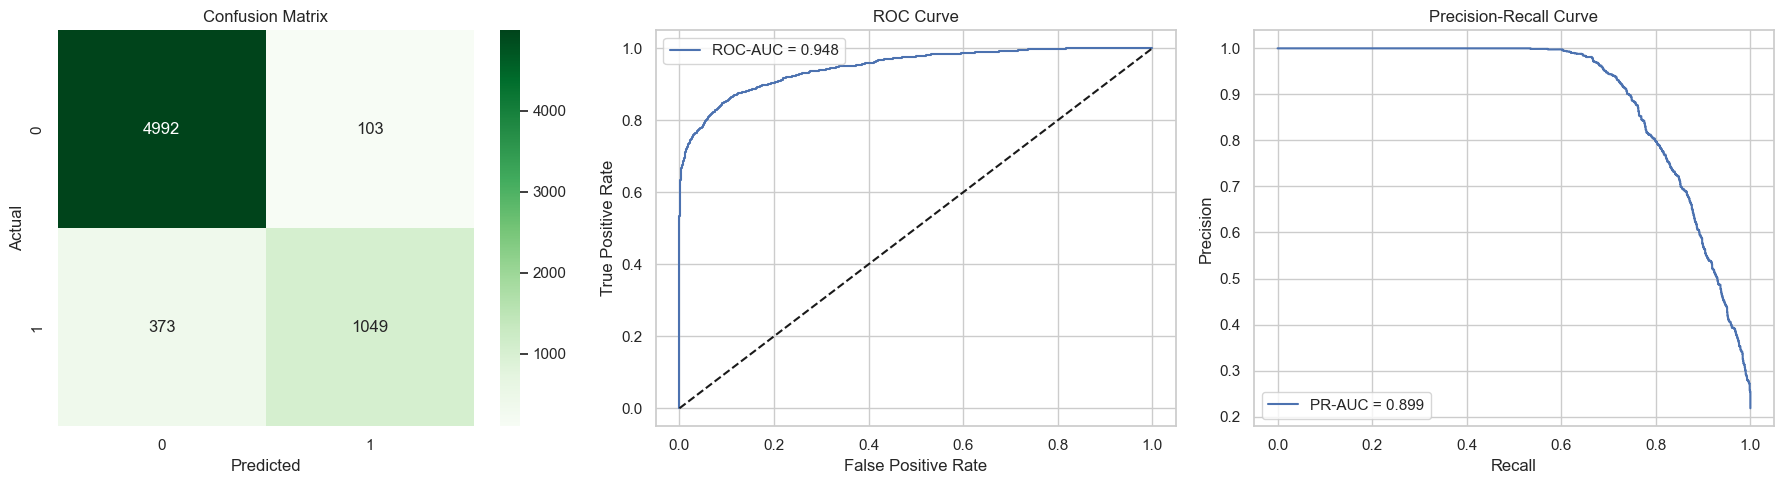

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, final_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, final_test_prob)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, final_test_prob):.3f}")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

precision, recall, _ = precision_recall_curve(y_test, final_test_prob)
axes[2].plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test, final_test_prob):.3f}")
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.tight_layout()
plt.show()

## Probability Calibration for PD Estimates

The final refit classifier is best for classification metrics. For probability-of-default estimates, calibration is evaluated separately by training on the training split and calibrating on validation data.

,model,roc_auc,pr_auc,brier
0,Uncalibrated XGBoost,0.9420,0.8942,0.0652
1,Sigmoid-calibrated XGBoost,0.9420,0.8942,0.0594


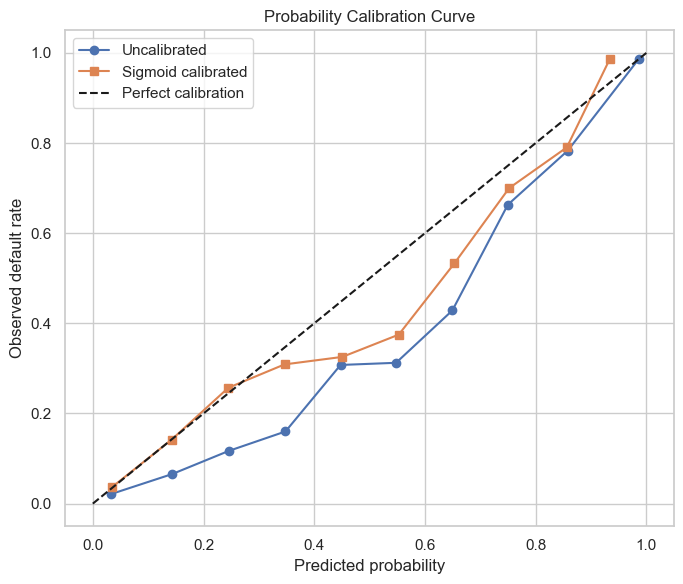

In [14]:
pd_base_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params,
)
pd_base_pipeline = make_pipeline(pd_base_model, X.columns.tolist(), add_missing_indicators=True, scale_numeric=True)
pd_base_pipeline.fit(X_train, y_train)
uncalibrated_prob = pd_base_pipeline.predict_proba(X_test)[:, 1]

sigmoid_calibrated = CalibratedClassifierCV(pd_base_pipeline, method="sigmoid", cv="prefit")
sigmoid_calibrated.fit(X_val, y_val)
calibrated_prob = sigmoid_calibrated.predict_proba(X_test)[:, 1]

calibration_summary = pd.DataFrame([
    {
        "model": "Uncalibrated XGBoost",
        "roc_auc": roc_auc_score(y_test, uncalibrated_prob),
        "pr_auc": average_precision_score(y_test, uncalibrated_prob),
        "brier": brier_score_loss(y_test, uncalibrated_prob),
    },
    {
        "model": "Sigmoid-calibrated XGBoost",
        "roc_auc": roc_auc_score(y_test, calibrated_prob),
        "pr_auc": average_precision_score(y_test, calibrated_prob),
        "brier": brier_score_loss(y_test, calibrated_prob),
    },
])
display(calibration_summary.style.format({"roc_auc": "{:.4f}", "pr_auc": "{:.4f}", "brier": "{:.4f}"}))

prob_true_uncal, prob_pred_uncal = calibration_curve(y_test, uncalibrated_prob, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calibrated_prob, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred_uncal, prob_true_uncal, marker="o", label="Uncalibrated")
plt.plot(prob_pred_cal, prob_true_cal, marker="s", label="Sigmoid calibrated")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed default rate")
plt.title("Probability Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

## Decile Calibration View

The assignment asks for predicted vs. actual default rates in decile bins. The table and plot below use calibrated probabilities on the held-out test set.

,risk_decile,borrowers,avg_predicted_pd,actual_default_rate
0,1,652,2.02%,0.00%
1,2,652,2.14%,1.69%
2,3,651,2.41%,2.30%
3,4,652,2.85%,3.07%
4,5,652,3.60%,4.91%
5,6,651,5.03%,5.99%
6,7,652,8.62%,10.12%
7,8,651,21.51%,21.51%
8,9,652,74.59%,68.56%
9,10,652,93.84%,100.00%


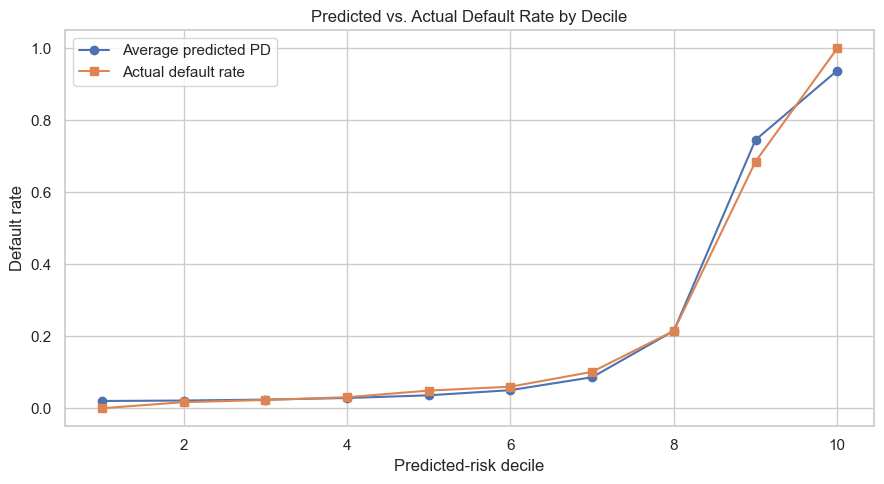

In [15]:
decile_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted_pd": calibrated_prob,
})
decile_df["risk_decile"] = pd.qcut(decile_df["predicted_pd"], 10, labels=False, duplicates="drop") + 1

decile_summary = (
    decile_df.groupby("risk_decile")
    .agg(
        borrowers=("actual", "size"),
        avg_predicted_pd=("predicted_pd", "mean"),
        actual_default_rate=("actual", "mean"),
    )
    .reset_index()
)

display(decile_summary.style.format({
    "avg_predicted_pd": "{:.2%}",
    "actual_default_rate": "{:.2%}",
}))

plt.figure(figsize=(9, 5))
plt.plot(decile_summary["risk_decile"], decile_summary["avg_predicted_pd"], marker="o", label="Average predicted PD")
plt.plot(decile_summary["risk_decile"], decile_summary["actual_default_rate"], marker="s", label="Actual default rate")
plt.xlabel("Predicted-risk decile")
plt.ylabel("Default rate")
plt.title("Predicted vs. Actual Default Rate by Decile")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance

Feature importances are extracted from the final XGBoost model after preprocessing. These importances are model-specific and should be interpreted as predictive signal, not causal explanation.

,feature,importance
21,cat__Home_OWN,0.125890
22,cat__Home_RENT,0.113667
8,num__Loan_to_Income,0.078206
28,cat__Intent_VENTURE,0.066383
4,num__Rate,0.064804
25,cat__Intent_HOMEIMPROVEMENT,0.057762
19,cat__Home_MORTGAGE,0.055769
6,num__Default,0.045664
1,num__Income,0.044978
5,num__Percent_income,0.041858


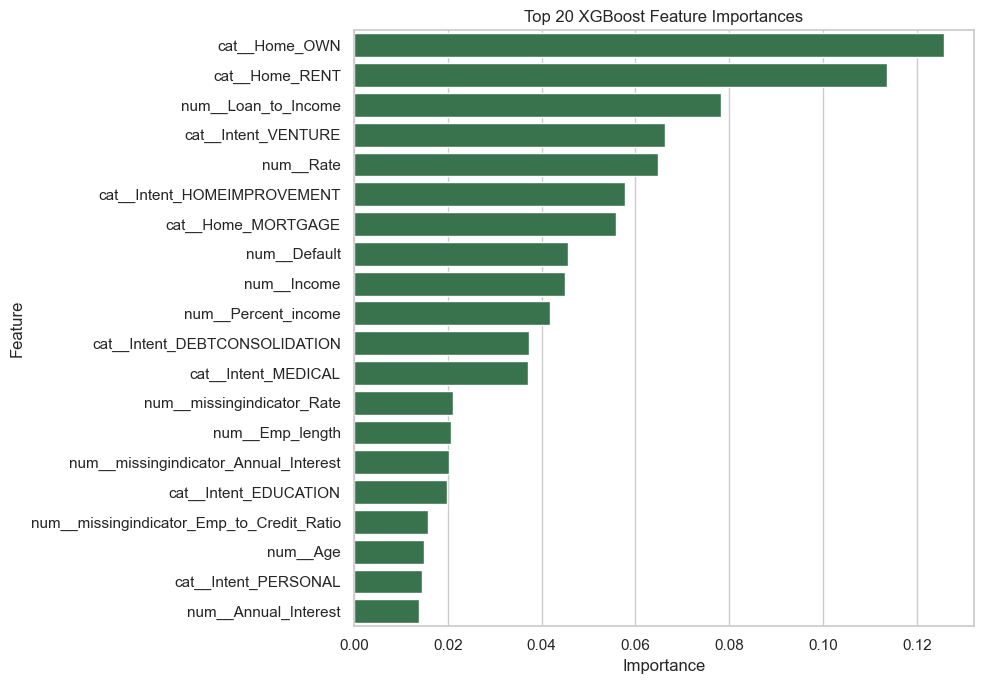

In [16]:
def get_feature_names_from_pipeline(pipeline):
    preprocessor = pipeline.named_steps["preprocess"]
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        numeric_features = preprocessor.transformers_[0][2]
        cat_pipeline = preprocessor.named_transformers_["cat"]
        cat_features = cat_pipeline.named_steps["onehot"].get_feature_names_out(preprocessor.transformers_[1][2])
        return np.array(list(numeric_features) + list(cat_features))

feature_names = get_feature_names_from_pipeline(final_pipeline)
importances = final_pipeline.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

display(importance_df)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x="importance", y="feature", color="#2f7d4b")
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Main Takeaways and Business Implications

**Problem statement:** estimate a borrower's probability of default so a lender can rank risk, support underwriting decisions, and monitor portfolio quality.

**Approach:** raw data was split into train/validation/test sets; preprocessing and feature engineering were fitted inside sklearn pipelines; multiple models were compared; XGBoost was tuned using cross-validation; the classification threshold was selected on validation data; final metrics were reported once on the held-out test set.

**Modeling insight:** XGBoost gave the strongest overall performance among the tested models. Logistic Regression remains useful as an interpretable baseline, but tree-based models captured nonlinear risk relationships better.

**Top risk factors:** home ownership category, loan-to-income ratio, interest rate, prior default history, income, loan percent of income, and loan intent were among the strongest predictors.

**Calibration insight:** sigmoid calibration improved probability quality, making predicted probability of default more suitable for business use than the raw model score alone.

**Business implications:** the model can help prioritize manual review, identify high-risk applications, support risk-based pricing, and reduce missed defaults. It should be used as decision support with human oversight, fairness monitoring, and periodic retraining.